                                                |BAIGIAMASIS DARBAS|                                                                    
1 dalis. Duomenų įkėlimas ir apžvalga

1.	Įkelkite failą pardavimai_nan.csv į pandas DataFrame.

2.	Išveskite:
o	eilučių ir stulpelių skaičių
o	stulpelių pavadinimus
o	duomenų tipus

3.	Patikrinkite:
o	ar yra trūkstamų (NaN) reikšmių
o	kuriuose stulpeliuose jos yra ir kiek jų

In [1]:
import pandas as pd

duomenys = pd.read_csv('pardavimai_nan.csv')

#Stulpeliu ir eiluciu kiekis
print("Eiluciu yra:", duomenys.shape[0])
print("Stulpeliu yra:", duomenys.shape[1],'\n')

#Stulpeliu pavadinimai ir duomenu tipai
print("Stulpeliu pavadinimai ir duomenu tipai:")
print(duomenys.dtypes,'\n')

#Patikriname ar yra tuscios reiksmes, jas susumuojame ir parodome, kuriuose stulpeliuose yra NaN reiksmes
print("Tikriname ir sumuojame tuscias reiksmes:", duomenys.isna().sum())
print("\nMatome, kad stulpelyje BuyerSatisfaction yra tusciu reiksmiu, ju yra 501\n")

Eiluciu yra: 10000
Stulpeliu yra: 11 

Stulpeliu pavadinimai ir duomenu tipai:
id                     int64
productsCount          int64
orderPrice           float64
buyer                    str
buyerCity                str
orderStatus              str
shippingPrice        float64
orderDate                str
orderTime                str
type                     str
buyerSatisfaction    float64
dtype: object 

Tikriname ir sumuojame tuscias reiksmes: id                     0
productsCount          0
orderPrice             0
buyer                  0
buyerCity              0
orderStatus            0
shippingPrice          0
orderDate              0
orderTime              0
type                   0
buyerSatisfaction    501
dtype: int64

Matome, kad stulpelyje BuyerSatisfaction yra tusciu reiksmiu, ju yra 501



2 dalis. Analizė (pasirinkti – 3 punktus)

Bent vienas punktas turi būti apskaičiuotas nenaudojant pandas agregavimo funkcijų (groupby, sum, mean). Turi būti naudojams for/while ciklas (nenaudoti pandas apply)

2.1 Pagrindiniai rodikliai
Apskaičiuokite ir išveskite:
•	bendrą užsakymų skaičių
•	bendrą pardavimų sumą (užsakymo suma + pristatymas)
•	vidutinę užsakymo vertę
•	vidutinį nupirktų prekių kiekį viename užsakyme
•	unikalių pirkėjų skaičių

In [4]:
import pandas as pd

duomenys = pd.read_csv('pardavimai_nan.csv')

#Apskaiciuojame bendra uzsakymu skaiciu
uzsakymu_kiekis = duomenys['id'].count()

#Sukuriame nauja stulpeli ir suskaiciuojame bendra pardavimu suma
duomenys['totalPrice'] = round(duomenys['orderPrice'] + duomenys['shippingPrice'],2)
bendra_pardavimu_suma = duomenys['totalPrice'].sum()

#Apskaiciuojame vidutine uzsakymo verte ir vidutini nupirktu prekiu kieki viename uzsakyme
uzsakymo_suma = 0
kiekio_suma = 0

for skaicius in duomenys['totalPrice']:
    uzsakymo_suma += skaicius
vidutine_uzsakymo_verte = round(uzsakymo_suma/uzsakymu_kiekis,2)

for kiekis in duomenys['productsCount']:
    kiekio_suma += kiekis
vidutinis_nupirktas_kiekis = round(kiekio_suma/uzsakymu_kiekis,2)

#Apskaiciuojame unikaliu pirkeju skaiciu
unikalus_pirkejai = duomenys['buyer'].nunique()

print('Bendras uzsakymu skaicius yra:', uzsakymu_kiekis)
print('Bendra pardavimu suma yra:', bendra_pardavimu_suma, 'euru')
print("Vidutine uzsakymo verte yra:", vidutine_uzsakymo_verte, 'euru')
print("Vidutinis nupirktu prekiu skaicius viename uzsakyme yra:", vidutinis_nupirktas_kiekis, 'vnt.')
print("Unikaliu pirkeju skaicius yra:", unikalus_pirkejai, 'pirkejai')

Bendras uzsakymu skaicius yra: 10000
Bendra pardavimu suma yra: 587355.52 euru
Vidutine uzsakymo verte yra: 58.74 euru
Vidutinis nupirktu prekiu skaicius viename uzsakyme yra: 3.14 vnt.
Unikaliu pirkeju skaicius yra: 806 pirkejai


2.2 Analizė pagal miestus

1.	Apskaičiuokite bendrą pardavimų sumą kiekviename mieste.

2.	Išveskite:
o	TOP 5 miestus pagal pardavimų sumą
o	miestą, kuriame buvo daugiausiai užsakymų


In [5]:
#Uzduotis 2.2.1
import pandas as pd

duomenys = pd.read_csv('pardavimai_nan.csv')

#Sukuriame nauja stulpeli ir apskaiciuojame bendra pardavimu suma
duomenys['totalPrice'] = round(duomenys['orderPrice'] + duomenys['shippingPrice'],2)

#Sugrupuojame miestus pagal bendra pardavimu suma ir pakeiciame stulpeliu pavadinimus
print("Sugrupuoti miestai pagal bendra pardavimu suma:")
miestai = duomenys.groupby('buyerCity')['totalPrice'].sum().sort_values(ascending=False).reset_index() \
.rename(columns={'buyerCity': 'Pirkejo miestas', 'totalPrice': 'Pardavimu suma, €'})

#Pakeiciame indeksa
miestai.index = range(1, len(miestai) +1)
miestai

Sugrupuoti miestai pagal bendra pardavimu suma:


,Pirkejo miestas,"Pardavimu suma, €"
1,Zarasai,53098.59
2,Šilutė,51772.62
3,Kėdainiai,42615.64
4,Kaišiadorys,42357.49
5,Šiauliai,15687.02
6,Klaipėda,15172.45
7,Vilnius,14665.09
8,Kaunas,11282.17
9,Visaginas,10972.98
10,Telšiai,10816.80


In [6]:
#Uzduotis 2.2.2
import pandas as pd

duomenys = pd.read_csv('pardavimai_nan.csv')

#Sukuriame nauja stulpeli ir apskaiciuojame bendra pardavimu suma
duomenys['totalPrice'] = round(duomenys['orderPrice'] + duomenys['shippingPrice'],2)

#Sugrupuojame miestus pagal bendra pardavimu suma ir randame TOP5 miestus
print("TOP5 miestai pagal bendra pardavimu suma:")
top5 = duomenys.groupby('buyerCity')['totalPrice'].sum().sort_values(ascending=False).head(5).reset_index() \
.rename(columns={'buyerCity': 'Pirkejo miestas', 'totalPrice': 'Pardavimu suma, €'})

#Pakeiciame indeksa
top5.index = range(1, len(top5) + 1)
top5

TOP5 miestai pagal bendra pardavimu suma:


,Pirkejo miestas,"Pardavimu suma, €"
1,Zarasai,53098.59
2,Šilutė,51772.62
3,Kėdainiai,42615.64
4,Kaišiadorys,42357.49
5,Šiauliai,15687.02


In [7]:
#Uzduotis 2.2.2
import pandas as pd

duomenys = pd.read_csv('pardavimai_nan.csv')

#Sukuriame nauja stulpeli ir irasome kiekis = 1
duomenys['orderCount'] = 1

#Grupuojame miestus pagal uzsakymu kieki ir randame miesta, kuris turi daugiausiai uzsakymu
print("Miestas, kuriame yra daugiausiai uzsakymu:")
miestas = duomenys.groupby('buyerCity')['orderCount'].count() \
    .sort_values(ascending=False).head(1).reset_index() \
    .rename(columns={'buyerCity': 'Pirkejo miestas', 'orderCount': 'Uzsakymu kiekis, vnt.'})

#Pakeiciame indeksa
miestas.index = range(1, len(miestas) +1)
miestas

Miestas, kuriame yra daugiausiai uzsakymu:


,Pirkejo miestas,"Uzsakymu kiekis, vnt."
1,Šilutė,930


2.3 Užsakymų būsenos analizė

1.	Suskaičiuokite, kiek yra kiekvienos orderStatus reikšmės.

2.	Apskaičiuokite:
o	kiek procentų užsakymų yra sėkmingi (pvz. completed)
o	kiek procentų – atšaukti

Rezultatus pateikite tvarkingoje lentelėje.


In [8]:
#Uzduotis 2.3.1
import pandas as pd

duomenys = pd.read_csv('pardavimai_nan.csv')

#Sukuriame nauja stulpeli ir irasome kiekis = 1
duomenys['orderCount'] = 1

#Apskaiciuojame kokios yra orderStatus reiksmes ir ju kiekius
print("Uzsakymu kiekiai pagal uzsakymo busena:")
busenos = duomenys.groupby('orderStatus')['orderCount'].count() \
    .sort_values(ascending=False).reset_index() \
    .rename(columns={'orderStatus': 'Uzsakymo busena', 'orderCount': 'Uzsakymu kiekis, vnt.'})

#Pakeiciame indeksa
busenos.index = range(1, len(busenos) +1)
busenos

Uzsakymu kiekiai pagal uzsakymo busena:


,Uzsakymo busena,"Uzsakymu kiekis, vnt."
1,pristatytas,7176
2,atšauktas,739
3,naujas,728
4,patvirtintas,696
5,išsiųstas,661


In [9]:
#Uzduotis 2.3.2
import pandas as pd

duomenys = pd.read_csv('pardavimai_nan.csv')

#Sukuriame nauja stulpeli ir irasome kiekis = 1
duomenys['orderCount'] = 1

#Apskaiciuojame kiek procentu visu uzsakymu yra sekmingi (pristatytas)
uzsakymu_kiekis = duomenys['orderCount'].count()
pristatytas_kiekis = sum(duomenys['orderStatus'] == 'pristatytas')
pristatytas_procentais = pristatytas_kiekis*100/uzsakymu_kiekis
print(f'"Pristatytas" uzsakymai sudaro {pristatytas_procentais}% visu uzsakymu')

#Apskaiciuojame kiek procentu visu uzsakymu yra nesekmingi (atsaukti)
atsauktas_kiekis = sum(duomenys['orderStatus'] == 'atšauktas')
atsauktas_procentais = atsauktas_kiekis*100/uzsakymu_kiekis
print(f'"Atsauktas" uzsakymai sudaro {atsauktas_procentais}% visu uzsakymu','\n')
print("Uzsakymu kiekiai ir procentine dalis nuo visu uzsakymu pagal uzsakymo busena:")

#Kuriame pivot lentele su pateiktais duomenimis
pivot = pd.pivot_table(
    duomenys,
    index='orderStatus',
    values='orderCount',
    aggfunc='count'
)

pivot['percentageOfTotal'] = pivot['orderCount'] / pivot['orderCount'].sum() * 100
pivot = pivot.reset_index().rename(columns={'orderStatus': 'Uzsakymo busena', 'orderCount': 'Uzsakymu kiekis, vnt.', \
                                             'percentageOfTotal': 'Dalis nuo visu uzsakymu, %'})

#Pakeiciame indeksa
pivot.index = range(1, len(pivot) +1)
pivot

"Pristatytas" uzsakymai sudaro 71.76% visu uzsakymu
"Atsauktas" uzsakymai sudaro 7.39% visu uzsakymu 

Uzsakymu kiekiai ir procentine dalis nuo visu uzsakymu pagal uzsakymo busena:


,Uzsakymo busena,"Uzsakymu kiekis, vnt.","Dalis nuo visu uzsakymu, %"
1,atšauktas,739,7.39
2,išsiųstas,661,6.61
3,naujas,728,7.28
4,patvirtintas,696,6.96
5,pristatytas,7176,71.76


2.4 Darbas su datomis

1.	Paverskite orderDate stulpelį į datetime formatą.

2.	Apskaičiuokite:
o	pardavimų sumą pagal mėnesius

3.	Nustatykite:
o	pelningiausią mėnesį

In [10]:
#Uzduotis 2.4.1-2
import pandas as pd

duomenys = pd.read_csv('pardavimai_nan.csv')

#Paverciame orderDate stulpeli i datetime formata
duomenys['orderDate'] = pd.to_datetime(duomenys['orderDate'])

#Sukuriame nauja stulpeli ir apskaiciuojame bendra pardavimu suma
duomenys['totalPrice'] = round(duomenys['orderPrice'] + duomenys['shippingPrice'],2)

#Sukuriame nauja stulpeli, kuriame bus pazymetas menesiu skaicius
duomenys['Menuo'] = duomenys['orderDate'].dt.month

#Sugrupuojame menesius pagal bendrus pardavimus
print("Bendra pardavimu suma pagal menesi:")
menesiai = duomenys.groupby('Menuo')['totalPrice'].sum().reset_index() \
    .rename(columns={'totalPrice': 'Pardavimu suma, €'})

#Pakeiciame indeksa
menesiai.index = range(1, len(menesiai) +1)
menesiai

Bendra pardavimu suma pagal menesi:


,Menuo,"Pardavimu suma, €"
1,1,48432.09
2,2,47613.19
3,3,52563.06
4,4,51454.22
5,5,53398.93
6,6,44245.28
7,7,46717.70
8,8,47701.03
9,9,43025.54
10,10,52662.38


In [11]:
#Uzduotis 2.4.3
import pandas as pd

duomenys = pd.read_csv('pardavimai_nan.csv')

#Paverciame orderDate stulpeli i datetime formata
duomenys['orderDate'] = pd.to_datetime(duomenys['orderDate'])

#Sukuriame nauja stulpeli ir apskaiciuojame bendra pardavimu suma
duomenys['totalPrice'] = round(duomenys['orderPrice'] + duomenys['shippingPrice'],2)

#Sukuriame nauja stulpeli, kuriame bus pazymetas menesiu skaicius
duomenys['Menuo'] = duomenys['orderDate'].dt.month

#Sugrupuojame menesius pagal bendrus pardavimus
duomenys.groupby('Menuo')['totalPrice'].sum().reset_index()

#Nustatome pelningiausia menesi
print("Pelningiausias menuo yra:")
menesiai = duomenys.groupby('Menuo')['totalPrice'].sum() \
    .sort_values(ascending=False).head(1).reset_index() \
        .rename(columns={'totalPrice': 'Pardavimu suma, €'})

#Pakeiciame indeksa
menesiai.index = range(1, len(menesiai) +1)
menesiai

Pelningiausias menuo yra:


,Menuo,"Pardavimu suma, €"
1,5,53398.93


2.5 Pirkėjų pasitenkinimas

1.	Apdorokite trūkstamas buyerSatisfaction reikšmes (paaiškinkite, ką su jomis darote).

2.	Apskaičiuokite:
o	vidutinį pirkėjų pasitenkinimą
o	vidutinį pasitenkinimą pagal užsakymo tipą (type)

3.	Nustatykite, kuris užsakymo tipas turi aukščiausią vidutinį įvertinimą.

In [12]:
#Uzduotis 2.5.1-2
import pandas as pd

duomenys = pd.read_csv('pardavimai_nan.csv')

#Kadangi NaN sudaro apie 5% visu duomenu ir mano naudojamos formules automatiskai ignoruoja NaN reiksmes, mes papildomai nieko nedarome.
#Patikrinimui istriniau trukstamas reiksmes su .dropna() funkcija ir atlikau tuos pacius skaiciavimus, rezultatas yra vienodas.
print("Mes NaN reiksmes paliekame, kadangi jos sudaro tik 5% visu duomenu ir mano skaiciavimo formules ignoruoja NaN reiksmes", '\n')

#Apskaiciuojame vidutini pirkeju pasitenkinima
vidutinis_pasitenkinimas = round(duomenys['buyerSatisfaction'].mean(),2)
print("Vidutinis klientu pasitenkinimas intervale (1-5) yra:", vidutinis_pasitenkinimas,'\n')

#Apskaiciuojame vidutini pasitenkinima pagal uzsakymo tipa
print("Vidutinis pasitenkinimas pagal uzsakymo tipa:")
tipai = round(duomenys.groupby('type')['buyerSatisfaction'].mean(),2).reset_index() \
    .rename(columns={'type': 'Uzsakymo tipas', 'buyerSatisfaction': 'Klientu pasitenkinimas, (1-5)'})

#Pakeiciame indeksa
tipai.index = range(1, len(tipai) +1)
tipai

Mes NaN reiksmes paliekame, kadangi jos sudaro tik 5% visu duomenu ir mano skaiciavimo formules ignoruoja NaN reiksmes 

Vidutinis klientu pasitenkinimas intervale (1-5) yra: 3.68 

Vidutinis pasitenkinimas pagal uzsakymo tipa:


,Uzsakymo tipas,"Klientu pasitenkinimas, (1-5)"
1,internetu,3.67
2,parduotuvėje,3.72


In [13]:
#Uzduotis 2.5.3
import pandas as pd

duomenys = pd.read_csv('pardavimai_nan.csv')

#Apskaiciuojame vidutini pasitenkinima pagal uzsakymo tipa
round(duomenys.groupby('type')['buyerSatisfaction'].mean(),2).reset_index()

#Nustatome uzsakymo tipa su auksciausiu vidutiniu ivertinimu
print("Uzsakymo tipas su auksciausiu vidutiniu ivertinimu yra:")
tipai = round(duomenys.groupby('type')['buyerSatisfaction'].mean(),2) \
    .sort_values(ascending=False).head(1).reset_index() \
        .rename(columns={'type': 'Uzsakymo tipas', 'buyerSatisfaction': 'Klientu pasitenkinimas, (1-5)'})

#Pakeiciame indeksa
tipai.index = range(1, len(tipai) +1)
tipai

Uzsakymo tipas su auksciausiu vidutiniu ivertinimu yra:


,Uzsakymo tipas,"Klientu pasitenkinimas, (1-5)"
1,parduotuvėje,3.72


3 dalis. Python/vizualizacija (pasirinkti – 1 punkta)

3.2 Nubraižykite grafiką 

Grafikui galima naudoti matplotlib, arba pandas integruotą braižymą (df.plot()).

Pvz.: 
* pardavimai pagal mėnesius
* pardavimai pagal miestus

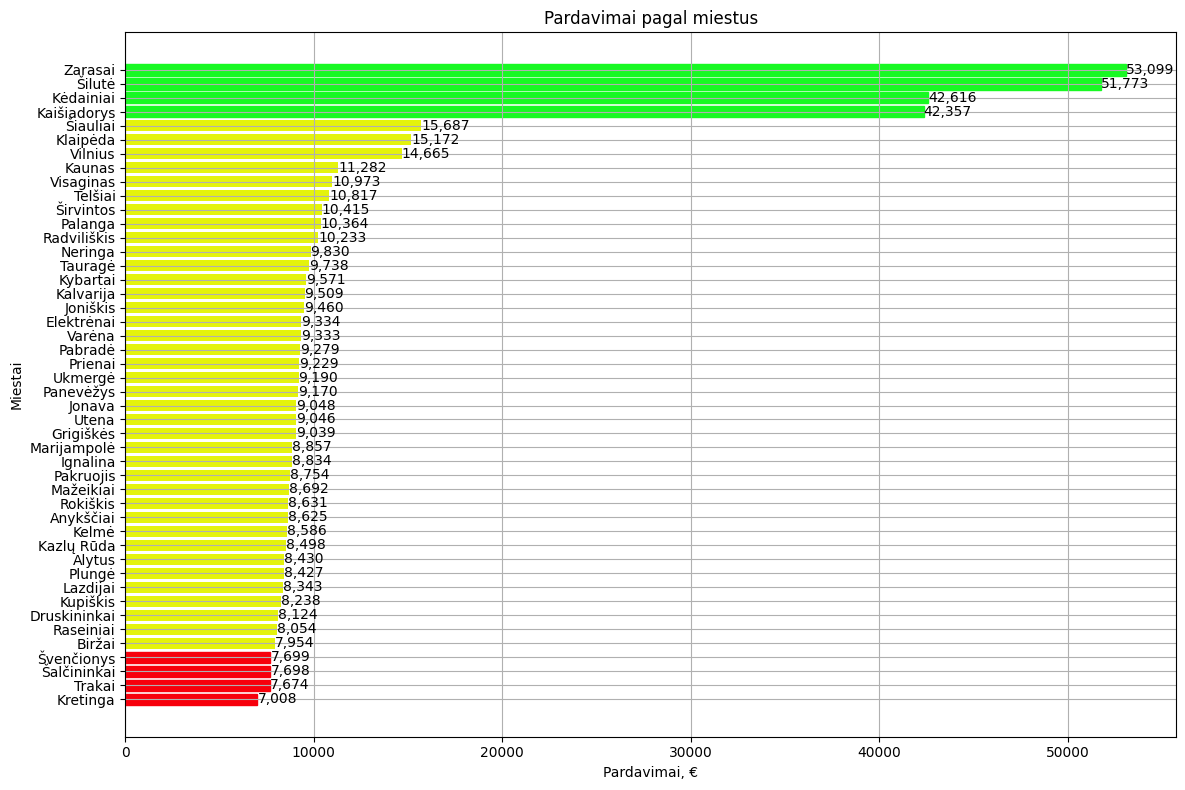

Remiantis grafiku matome, kad daugiausiai pardavimu turime Zarasuose, Siluteje, Kedainiuose ir Kaisiadoryje
Remiantis grafiku matome, kad maziausiai pardavimu turime Kretingoje, Trakuose, Salcininkuose ir Svencionyje


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

duomenys = pd.read_csv('pardavimai_nan.csv')

#Sukuriame papildoma stulpeli bendru pardavimu
duomenys['totalPrice'] = duomenys['orderPrice'] + duomenys['shippingPrice']

#Bendri pardavimai pagal miesta
pardavimai_pagal_miesta = duomenys.groupby('buyerCity')['totalPrice'].sum() \
    .sort_values(ascending=True).reset_index()
    
miestai = pardavimai_pagal_miesta['buyerCity']
pardavimai = pardavimai_pagal_miesta['totalPrice']

#Sukuriam stulpeline diagrama
plt.figure(figsize=(12, 8))

#Parenkam spalvas stulpeliams
stulpeliai = plt.barh(miestai, pardavimai, color="#e4f30c")
stulpeliai[45].set_color("#18F923")
stulpeliai[44].set_color("#18F923")
stulpeliai[43].set_color("#18F923")
stulpeliai[42].set_color("#18F923")
stulpeliai[0].set_color("#F7000C")
stulpeliai[1].set_color("#F7000C")
stulpeliai[2].set_color("#F7000C")
stulpeliai[3].set_color("#F7000C")

#Nustatom kitus parametrus
plt.bar_label(stulpeliai, fmt='{:,.0f}')
plt.title('Pardavimai pagal miestus')
plt.xlabel('Pardavimai, €')
plt.ylabel("Miestai")
plt.tight_layout()
plt.grid()
plt.show()

print("Remiantis grafiku matome, kad daugiausiai pardavimu turime Zarasuose, Siluteje, Kedainiuose ir Kaisiadoryje")
print("Remiantis grafiku matome, kad maziausiai pardavimu turime Kretingoje, Trakuose, Salcininkuose ir Svencionyje")

4 dalis. Papildomai (nebūtina)

4.1	Raskite užsakymus, kurių suma yra didesnė nei 95 % visų užsakymų

4.2	Raskite TOP 5 pirkėjus pagal išleistą sumą

4.3 Palyginkite vidutinę užsakymo vertę pagal užsakymo tipą

In [17]:
##4.4.2 uzduotis
import pandas as pd

duomenys = pd.read_csv("pardavimai_nan.csv")

#Sukuriame papildoma stulpeli bendru pardavimu ir uzsakymu skaiciaus
duomenys['totalPrice'] = duomenys['orderPrice'] + duomenys['shippingPrice']

duomenys['orderCount'] = 1

#Grupuojame pirkejus pagal isleista suma ir papildomai ziurime uzsakymu kiekius
print("TOP 5 pirkejai pagal isleista suma ir tu pirkeju uzsakymu kiekiai:")
top5 = duomenys.groupby('buyer')[['totalPrice', 'orderCount']].sum().sort_values(by='totalPrice', ascending=False).head(5).reset_index() \
    .rename(columns={'buyer': 'Pirkejas', 'totalPrice': 'Pardavimu suma, €','orderCount': 'Uzsakymu kiekis, vnt.'})

#Pakeiciame indeksa
top5.index = range(1, len(top5) +1)
top5

TOP 5 pirkejai pagal isleista suma ir tu pirkeju uzsakymu kiekiai:


,Pirkejas,"Pardavimu suma, €","Uzsakymu kiekis, vnt."
1,Jolanta R.,3174.20,44
2,Jolanta F.,2812.01,54
3,Aurimas J.,2766.30,40
4,Jolanta C.,2681.28,45
5,Aurimas M.,2677.19,41


In [18]:
##4.4.3 uzduotis
import pandas as pd

duomenys = pd.read_csv("pardavimai_nan.csv")

#Sukuriame papildoma stulpeli bendru pardavimu
duomenys['totalPrice'] = duomenys['orderPrice'] + duomenys['shippingPrice']

#Grupuojame uzsakymo tipus pagal vidutine uzsakymo verte
print("Vidutine uzsakymo verte pagal uzsakymo tipa:")
tipai = duomenys.groupby('type')['totalPrice'].mean().round(2).sort_values(ascending=False).reset_index() \
    .rename(columns={'type': 'Uzsakymo tipas', 'totalPrice': 'Pardavimu suma, €'})

#Pakeiciame indeksa
tipai.index = range(1, len(tipai) +1)
tipai

Vidutine uzsakymo verte pagal uzsakymo tipa:


,Uzsakymo tipas,"Pardavimu suma, €"
1,parduotuvėje,59.27
2,internetu,58.53


                                                |REZULTATU APIBENDRINIMAS|                                                          

1. Remiantis atlikta analize matome, kad pirkejai, kurie atliko uzsakymus parduotuveje, yra labiau patenkinti ir ju vidutine uzsakymo verte yra didesne, lyginant su pardavimais, atliktais internetu. Taciau sis skirtumas yra labai mazas.

2. Remiantis pateiktu grafiku matome, kad maziausiai pardavimu turime Kretingoje, Trakuose, Salcininkuose ir Svencionyje, tad siuose miestuose galima butu gerinti marketinga, kad padidintume pardavimus.

3. Remiantis atlikta analize matome, kad daugiausiai pardavimu turime pavasari, o maziausiai pardavimu turime vasara.

4. Remiantis atlikta analize matome, kad atsaukti uzsakymai sudaro net 7.39% nuo visu uzsakymu, tad reiketu ieskoti sprendimu siam procentui mazinti.